<a href="https://colab.research.google.com/github/Shivani-Yadav-CSE/Computer_vision_lab_files/blob/main/labsheet_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LABSHEET 04

Saving download (33).jpg to download (33).jpg
Image loaded successfully!
File name: download (33).jpg
Image size: (933, 700)


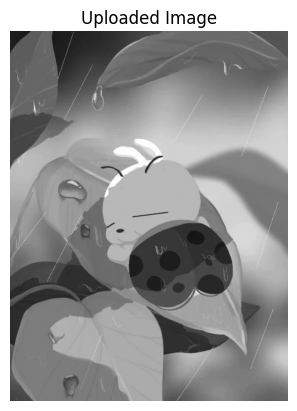

In [ ]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

image = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Image could not be loaded.")
else:
    print("Image loaded successfully!")
    print("File name:", file_name)
    print("Image size:", image.shape)

    plt.imshow(image, cmap="gray")
    plt.title("Uploaded Image")
    plt.axis("off")
    plt.show()

Q1.

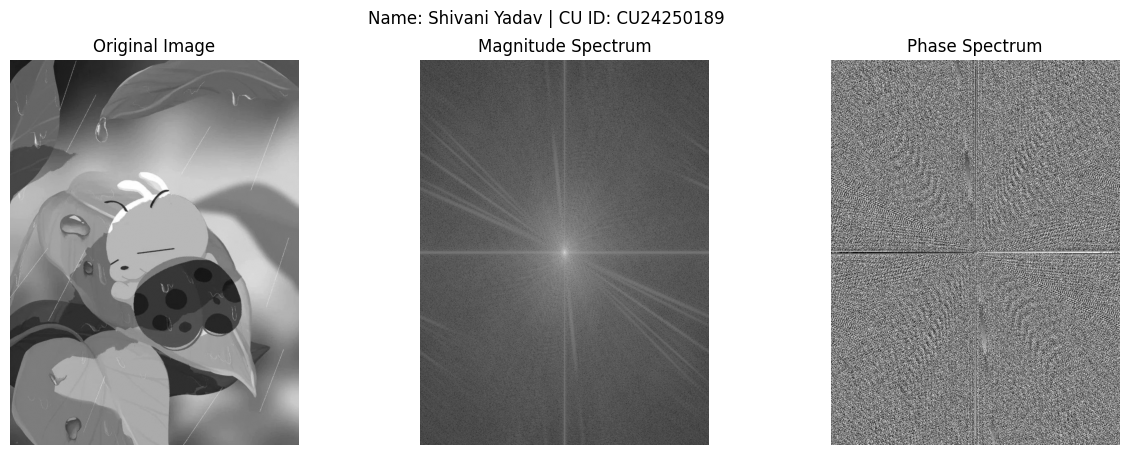

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Student Details
name = "Shivani Yadav"
cu_id = "CU24250189"

# Use the image uploaded earlier
image = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)

# Fourier Transform
dft = np.fft.fft2(image)

# Shift the frequency components
dft_shift = np.fft.fftshift(dft)

# Magnitude spectrum
magnitude = np.abs(dft_shift)
magnitude_spectrum = 20 * np.log(magnitude + 1)

# Phase spectrum
phase_spectrum = np.angle(dft_shift)

# Display
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(magnitude_spectrum, cmap="gray")
plt.title("Magnitude Spectrum")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(phase_spectrum, cmap="gray")
plt.title("Phase Spectrum")
plt.axis("off")

plt.suptitle(f"Name: {name} | CU ID: {cu_id}")
plt.show()

Q2.

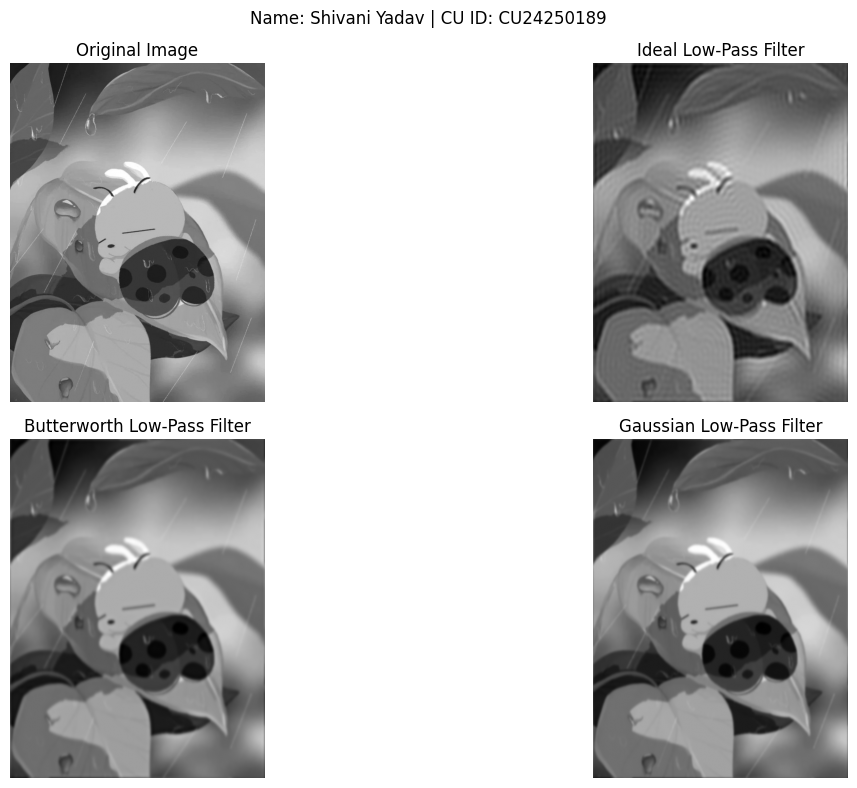

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Student Details
name = "Shivani Yadav"
cu_id = "CU24250189"

# Read image
image = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Image could not be loaded.")
else:
    rows, cols = image.shape
    center_row, center_col = rows // 2, cols // 2

    # Fourier Transform
    dft = np.fft.fft2(image)
    dft_shift = np.fft.fftshift(dft)

    # Distance matrix
    y, x = np.ogrid[:rows, :cols]
    distance = np.sqrt(
        (x - center_col) ** 2 +
        (y - center_row) ** 2
    )

    cutoff = 50

    # Ideal Low Pass Filter
    ideal = np.zeros((rows, cols))
    ideal[distance <= cutoff] = 1

    # Butterworth Low Pass Filter
    order = 2
    butterworth = 1 / (
        1 + (distance / cutoff) ** (2 * order)
    )

    # Gaussian Low Pass Filter
    gaussian = np.exp(
        -(distance ** 2) / (2 * cutoff ** 2)
    )

    # Apply filters
    ideal_result = dft_shift * ideal
    butter_result = dft_shift * butterworth
    gaussian_result = dft_shift * gaussian

    # Inverse Fourier Transform
    ideal_img = np.abs(
        np.fft.ifft2(np.fft.ifftshift(ideal_result))
    )

    butter_img = np.abs(
        np.fft.ifft2(np.fft.ifftshift(butter_result))
    )

    gaussian_img = np.abs(
        np.fft.ifft2(np.fft.ifftshift(gaussian_result))
    )

    # Display
    plt.figure(figsize=(15, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(2, 2, 2)
    plt.imshow(ideal_img, cmap="gray")
    plt.title("Ideal Low-Pass Filter")
    plt.axis("off")

    plt.subplot(2, 2, 3)
    plt.imshow(butter_img, cmap="gray")
    plt.title("Butterworth Low-Pass Filter")
    plt.axis("off")

    plt.subplot(2, 2, 4)
    plt.imshow(gaussian_img, cmap="gray")
    plt.title("Gaussian Low-Pass Filter")
    plt.axis("off")

    plt.suptitle(f"Name: {name} | CU ID: {cu_id}")
    plt.tight_layout()
    plt.show()

Q3.

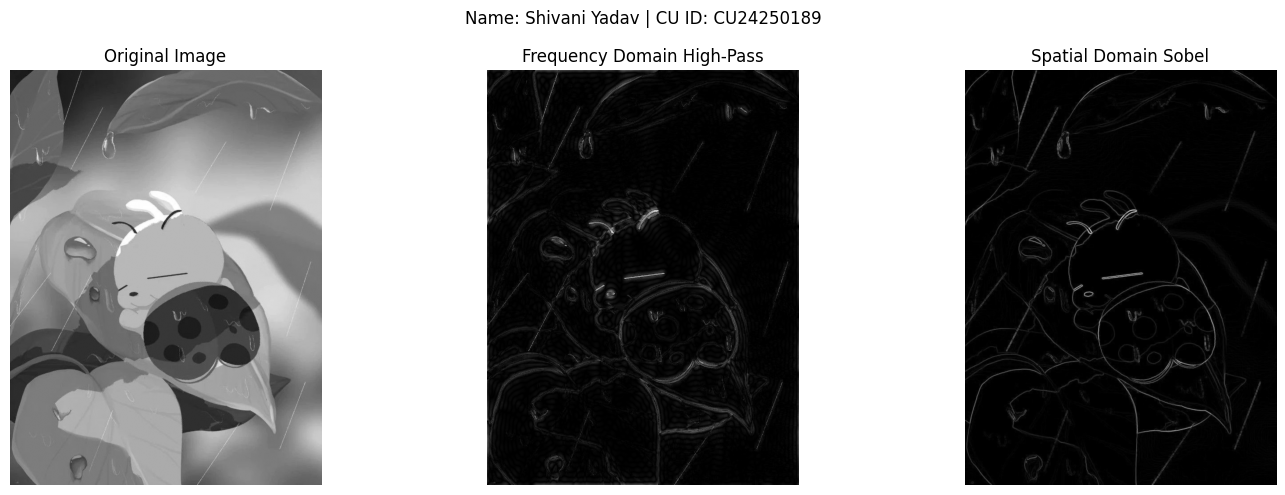

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Student Details
name = "Shivani Yadav"
cu_id = "CU24250189"

# Read image
image = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Image could not be loaded.")
else:
    rows, cols = image.shape
    center_row, center_col = rows // 2, cols // 2

    # Fourier Transform
    dft = np.fft.fft2(image)
    dft_shift = np.fft.fftshift(dft)

    # Distance from frequency center
    y, x = np.ogrid[:rows, :cols]
    distance = np.sqrt(
        (x - center_col) ** 2 +
        (y - center_row) ** 2
    )

    cutoff = 40

    # High-pass mask
    high_pass = np.ones((rows, cols))
    high_pass[distance <= cutoff] = 0

    # Apply high-pass filter
    filtered_spectrum = dft_shift * high_pass

    # Inverse Fourier Transform
    frequency_edges = np.abs(
        np.fft.ifft2(
            np.fft.ifftshift(filtered_spectrum)
        )
    )

    # Sobel edge detection
    sobel_x = cv2.Sobel(
        image, cv2.CV_64F, 1, 0, ksize=3
    )

    sobel_y = cv2.Sobel(
        image, cv2.CV_64F, 0, 1, ksize=3
    )

    sobel_edges = cv2.magnitude(sobel_x, sobel_y)

    # Display
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(frequency_edges, cmap="gray")
    plt.title("Frequency Domain High-Pass")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(sobel_edges, cmap="gray")
    plt.title("Spatial Domain Sobel")
    plt.axis("off")

    plt.suptitle(f"Name: {name} | CU ID: {cu_id}")
    plt.tight_layout()
    plt.show()

Q4.

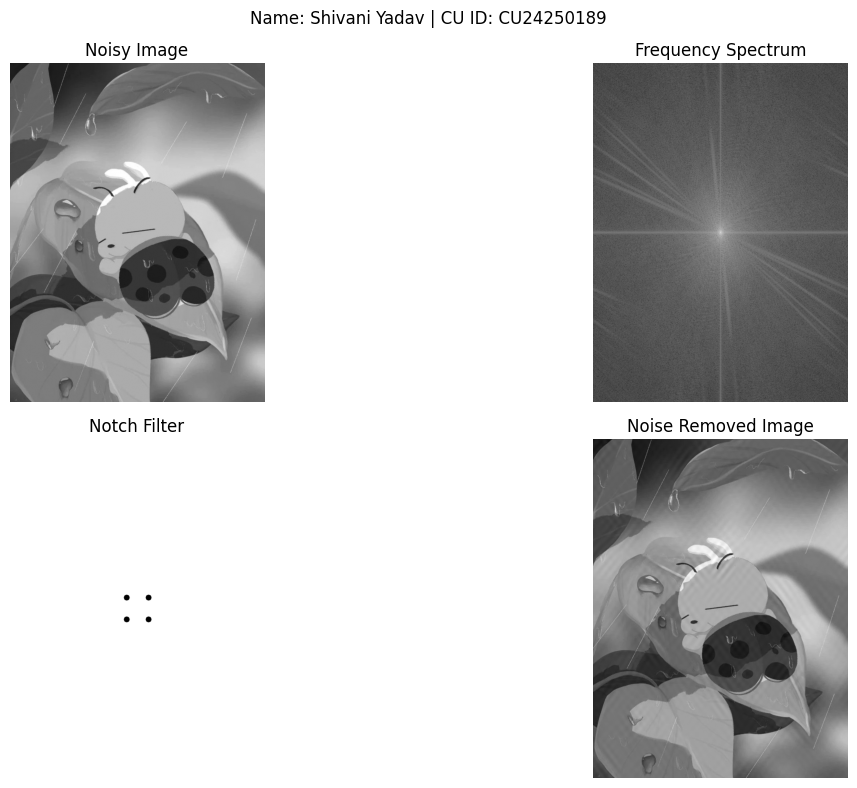

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Student Details
name = "Shivani Yadav"
cu_id = "CU24250189"

# Read noisy image
image = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Noisy image could not be loaded.")
else:
    rows, cols = image.shape
    center_row, center_col = rows // 2, cols // 2

    # Fourier Transform
    dft = np.fft.fft2(image)
    dft_shift = np.fft.fftshift(dft)

    # Magnitude spectrum
    magnitude = np.abs(dft_shift)
    spectrum = np.log1p(magnitude)

    # Create notch filter
    notch_filter = np.ones((rows, cols))

    # Example noise spike locations
    spike_points = [
        (center_row - 30, center_col - 30),
        (center_row + 30, center_col + 30),
        (center_row - 30, center_col + 30),
        (center_row + 30, center_col - 30)
    ]

    radius = 8

    y, x = np.ogrid[:rows, :cols]

    # Suppress selected frequency spikes
    for point_y, point_x in spike_points:
        distance = np.sqrt(
            (x - point_x) ** 2 +
            (y - point_y) ** 2
        )

        notch_filter[distance <= radius] = 0

    # Apply notch filter
    filtered_spectrum = dft_shift * notch_filter

    # Inverse Fourier Transform
    restored_image = np.abs(
        np.fft.ifft2(
            np.fft.ifftshift(filtered_spectrum)
        )
    )

    # Display
    plt.figure(figsize=(15, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Noisy Image")
    plt.axis("off")

    plt.subplot(2, 2, 2)
    plt.imshow(spectrum, cmap="gray")
    plt.title("Frequency Spectrum")
    plt.axis("off")

    plt.subplot(2, 2, 3)
    plt.imshow(notch_filter, cmap="gray")
    plt.title("Notch Filter")
    plt.axis("off")

    plt.subplot(2, 2, 4)
    plt.imshow(restored_image, cmap="gray")
    plt.title("Noise Removed Image")
    plt.axis("off")

    plt.suptitle(f"Name: {name} | CU ID: {cu_id}")
    plt.tight_layout()
    plt.show()

Q5.

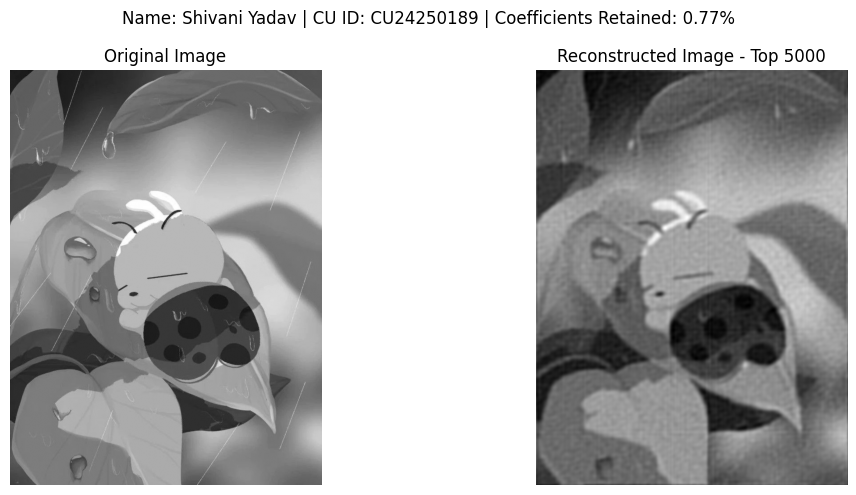

Total Fourier coefficients: 653100
Coefficients retained: 5000
Percentage retained: 0.77%


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Student Details
name = "Shivani Yadav"
cu_id = "CU24250189"

# Read image
image = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Image could not be loaded.")
else:
    # Fourier Transform
    dft = np.fft.fft2(image)
    dft_shift = np.fft.fftshift(dft)

    # Calculate magnitude
    magnitude = np.abs(dft_shift)

    # Select number of coefficients
    K = 5000

    # Flatten magnitude array
    flat_magnitude = magnitude.flatten()

    # Find indices of top-K coefficients
    top_indices = np.argpartition(
        flat_magnitude, -K
    )[-K:]

    # Create compressed spectrum
    compressed_dft = np.zeros_like(dft_shift)

    # Flatten both arrays
    compressed_flat = compressed_dft.flatten()
    original_flat = dft_shift.flatten()

    # Keep only top-K coefficients
    compressed_flat[top_indices] = original_flat[top_indices]

    # Restore 2D shape
    compressed_dft = compressed_flat.reshape(
        dft_shift.shape
    )

    # Inverse Fourier Transform
    reconstructed = np.abs(
        np.fft.ifft2(
            np.fft.ifftshift(compressed_dft)
        )
    )

    # Calculate retained percentage
    total_coefficients = image.size
    percentage = (K / total_coefficients) * 100

    # Display
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"Reconstructed Image - Top {K}")
    plt.axis("off")

    plt.suptitle(
        f"Name: {name} | CU ID: {cu_id} | "
        f"Coefficients Retained: {percentage:.2f}%"
    )

    plt.tight_layout()
    plt.show()

    print("Total Fourier coefficients:", total_coefficients)
    print("Coefficients retained:", K)
    print(f"Percentage retained: {percentage:.2f}%")

Upload the watermark image:


Saving download (33).jpg to download (33) (1).jpg


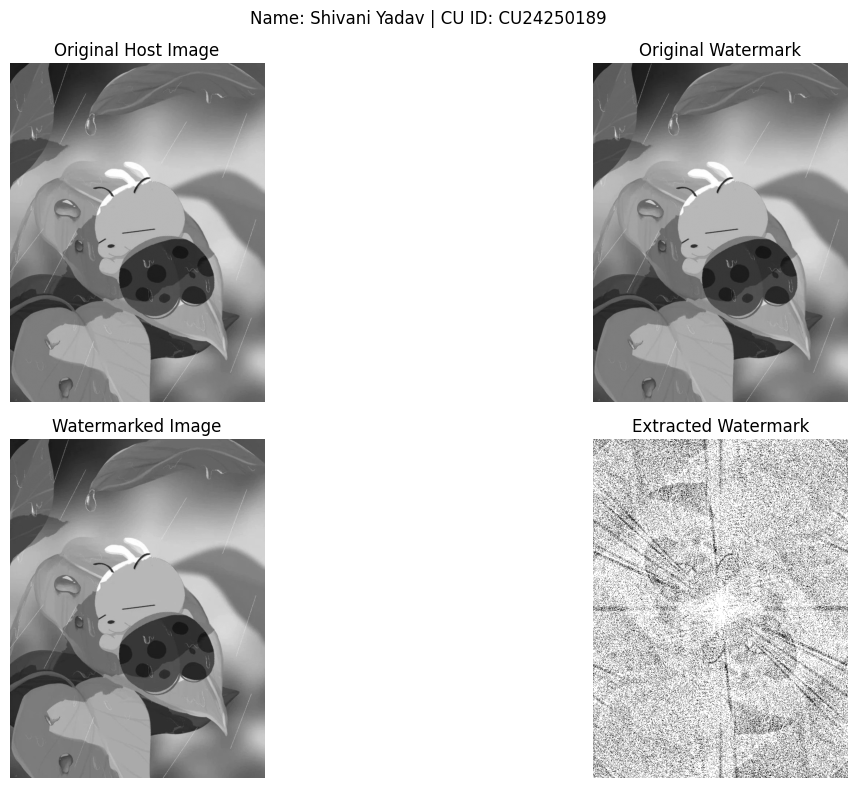

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Student Details
name = "Shivani Yadav"
cu_id = "CU24250189"

# Read host image
host = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)

# Upload watermark
from google.colab import files

print("Upload the watermark image:")
watermark_upload = files.upload()
watermark_name = list(watermark_upload.keys())[0]

watermark = cv2.imread(
    watermark_name,
    cv2.IMREAD_GRAYSCALE
)

# Resize watermark
watermark = cv2.resize(
    watermark,
    (host.shape[1], host.shape[0])
)

# Normalize watermark
watermark = watermark / 255.0

# Fourier Transform
host_dft = np.fft.fft2(host)
host_shift = np.fft.fftshift(host_dft)

# Watermark strength
alpha = 20

# Embed watermark into magnitude
magnitude = np.abs(host_shift)
phase = np.angle(host_shift)

modified_magnitude = magnitude + alpha * watermark

# Reconstruct complex spectrum
watermarked_spectrum = (
    modified_magnitude *
    np.exp(1j * phase)
)

# Inverse Fourier Transform
watermarked_image = np.abs(
    np.fft.ifft2(
        np.fft.ifftshift(watermarked_spectrum)
    )
)

watermarked_image = np.clip(
    watermarked_image, 0, 255
).astype(np.uint8)

# Extract watermark
watermarked_dft = np.fft.fft2(watermarked_image)
watermarked_shift = np.fft.fftshift(watermarked_dft)

new_magnitude = np.abs(watermarked_shift)

extracted = (
    new_magnitude - magnitude
) / alpha

extracted = np.clip(extracted, 0, 1)

# Display
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(host, cmap="gray")
plt.title("Original Host Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(watermark, cmap="gray")
plt.title("Original Watermark")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(watermarked_image, cmap="gray")
plt.title("Watermarked Image")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(extracted, cmap="gray")
plt.title("Extracted Watermark")
plt.axis("off")

plt.suptitle(
    f"Name: {name} | CU ID: {cu_id}"
)

plt.tight_layout()
plt.show()

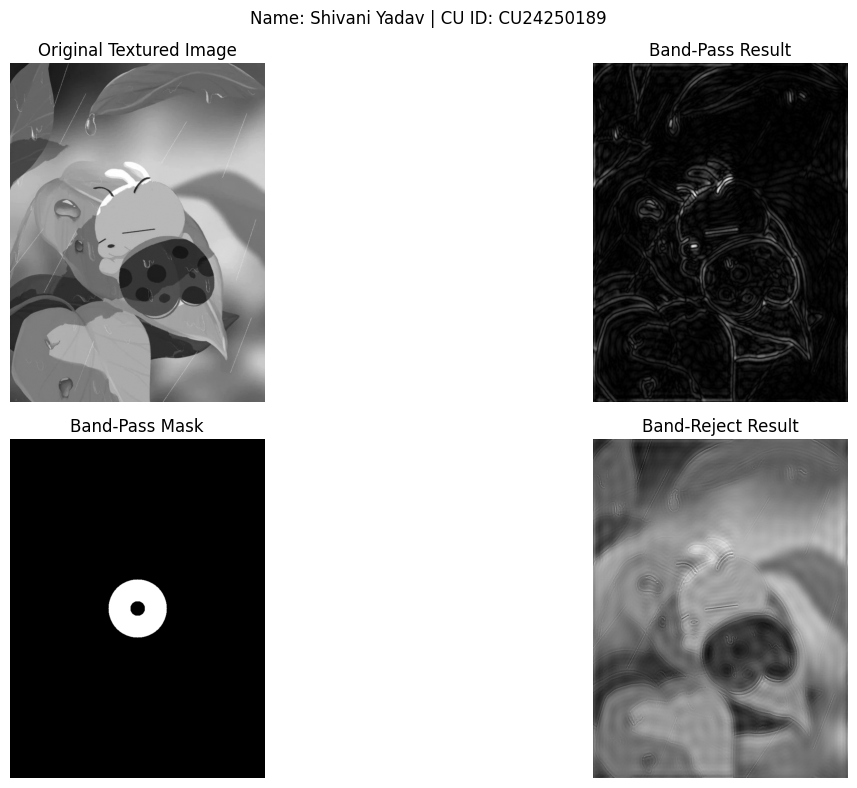

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Student Details
name = "Shivani Yadav"
cu_id = "CU24250189"

# Read image
image = cv2.imread(
    file_name,
    cv2.IMREAD_GRAYSCALE
)

rows, cols = image.shape

center_row = rows // 2
center_col = cols // 2

# Fourier Transform
dft = np.fft.fft2(image)
dft_shift = np.fft.fftshift(dft)

# Distance matrix
y, x = np.ogrid[:rows, :cols]

distance = np.sqrt(
    (x - center_col) ** 2 +
    (y - center_row) ** 2
)

# Frequency limits
low_cutoff = 20
high_cutoff = 80

# Band-pass filter
band_pass = np.zeros((rows, cols))
band_pass[
    (distance >= low_cutoff) &
    (distance <= high_cutoff)
] = 1

# Band-reject filter
band_reject = np.ones((rows, cols))
band_reject[
    (distance >= low_cutoff) &
    (distance <= high_cutoff)
] = 0

# Apply filters
bp_spectrum = dft_shift * band_pass
br_spectrum = dft_shift * band_reject

# Inverse Fourier Transform
band_pass_image = np.abs(
    np.fft.ifft2(
        np.fft.ifftshift(bp_spectrum)
    )
)

band_reject_image = np.abs(
    np.fft.ifft2(
        np.fft.ifftshift(br_spectrum)
    )
)

# Display
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Textured Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(band_pass_image, cmap="gray")
plt.title("Band-Pass Result")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(band_pass, cmap="gray")
plt.title("Band-Pass Mask")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(band_reject_image, cmap="gray")
plt.title("Band-Reject Result")
plt.axis("off")

plt.suptitle(
    f"Name: {name} | CU ID: {cu_id}"
)

plt.tight_layout()
plt.show()

Upload one image:


Saving download (34).jpg to download (34) (1).jpg


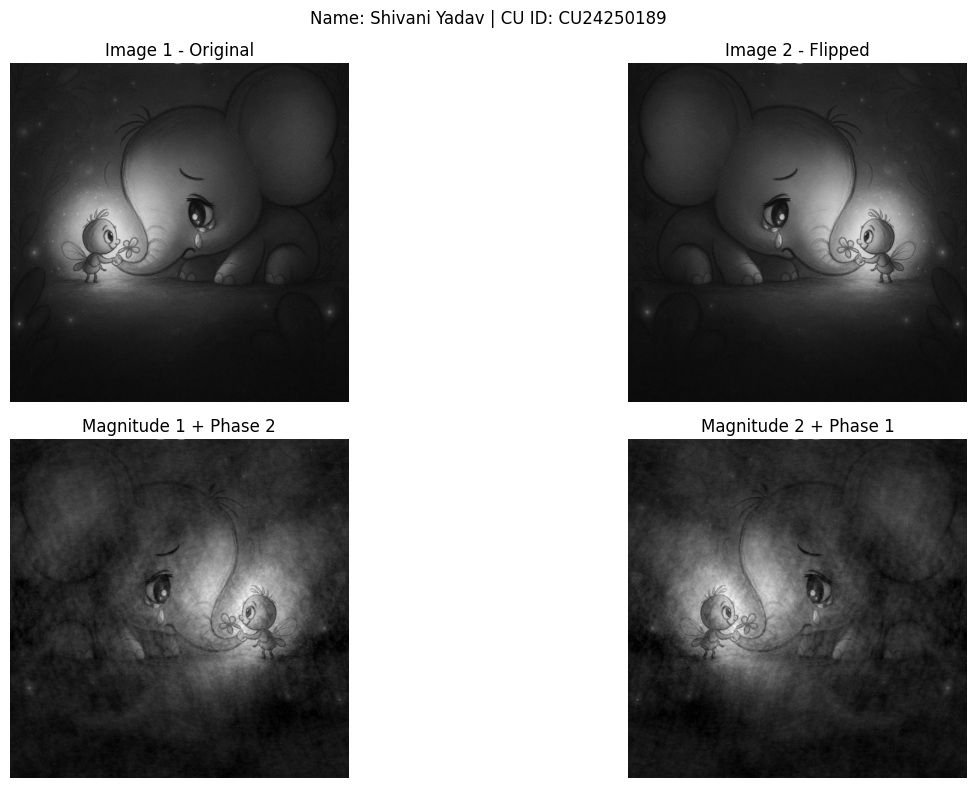

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Student Details
name = "Shivani Yadav"
cu_id = "CU24250189"

# Upload only ONE image
print("Upload one image:")
uploaded = files.upload()

# Get uploaded image name
image_name = list(uploaded.keys())[0]

# Read the uploaded image
image1 = cv2.imread(
    image_name,
    cv2.IMREAD_GRAYSCALE
)

# Check image
if image1 is None:
    print("Image could not be loaded.")
else:

    # Create Image 2 automatically
    # by flipping Image 1 horizontally
    image2 = cv2.flip(image1, 1)

    # Fourier Transform
    fft1 = np.fft.fft2(image1)
    fft2 = np.fft.fft2(image2)

    # Magnitude and Phase of Image 1
    magnitude1 = np.abs(fft1)
    phase1 = np.angle(fft1)

    # Magnitude and Phase of Image 2
    magnitude2 = np.abs(fft2)
    phase2 = np.angle(fft2)

    # Combine Magnitude 1 with Phase 2
    combined1 = (
        magnitude1 *
        np.exp(1j * phase2)
    )

    # Combine Magnitude 2 with Phase 1
    combined2 = (
        magnitude2 *
        np.exp(1j * phase1)
    )

    # Reconstruct images
    result1 = np.abs(
        np.fft.ifft2(combined1)
    )

    result2 = np.abs(
        np.fft.ifft2(combined2)
    )

    # Display results
    plt.figure(figsize=(15, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(image1, cmap="gray")
    plt.title("Image 1 - Original")
    plt.axis("off")

    plt.subplot(2, 2, 2)
    plt.imshow(image2, cmap="gray")
    plt.title("Image 2 - Flipped")
    plt.axis("off")

    plt.subplot(2, 2, 3)
    plt.imshow(result1, cmap="gray")
    plt.title("Magnitude 1 + Phase 2")
    plt.axis("off")

    plt.subplot(2, 2, 4)
    plt.imshow(result2, cmap="gray")
    plt.title("Magnitude 2 + Phase 1")
    plt.axis("off")

    plt.suptitle(
        f"Name: {name} | CU ID: {cu_id}"
    )

    plt.tight_layout()
    plt.show()

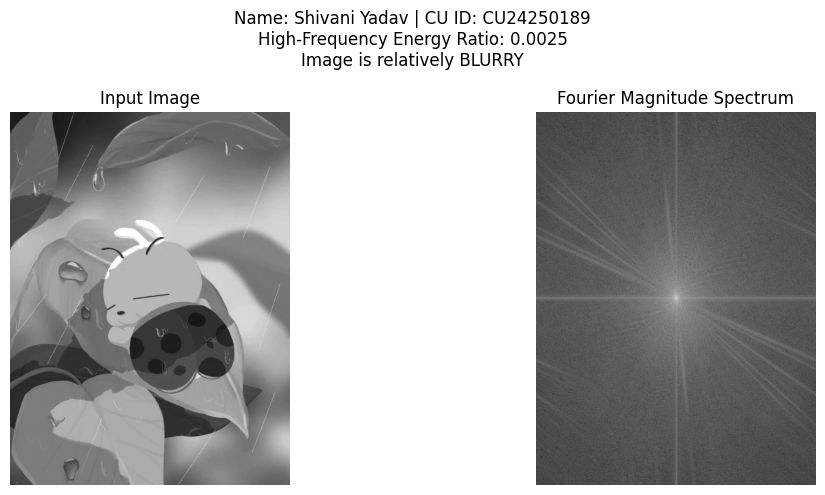

High-Frequency Energy Ratio: 0.0025303606873766315
Detection Result: Image is relatively BLURRY


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Student Details
name = "Shivani Yadav"
cu_id = "CU24250189"

# Read image
image = cv2.imread(
    file_name,
    cv2.IMREAD_GRAYSCALE
)

# Fourier Transform
dft = np.fft.fft2(image)
dft_shift = np.fft.fftshift(dft)

# Magnitude spectrum
magnitude = np.abs(dft_shift)

# Image dimensions
rows, cols = image.shape

center_row = rows // 2
center_col = cols // 2

# Create distance matrix
y, x = np.ogrid[:rows, :cols]

distance = np.sqrt(
    (x - center_col) ** 2 +
    (y - center_row) ** 2
)

# High-frequency region
high_frequency = distance > 60

# Calculate high-frequency energy
high_frequency_energy = np.sum(
    magnitude[high_frequency] ** 2
)

# Normalize energy
energy_ratio = (
    high_frequency_energy /
    np.sum(magnitude ** 2)
)

# Threshold
threshold = 0.10

if energy_ratio < threshold:
    result = "Image is relatively BLURRY"
else:
    result = "Image is relatively SHARP"

# Display
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    np.log1p(magnitude),
    cmap="gray"
)
plt.title("Fourier Magnitude Spectrum")
plt.axis("off")

plt.suptitle(
    f"Name: {name} | CU ID: {cu_id}\n"
    f"High-Frequency Energy Ratio: "
    f"{energy_ratio:.4f}\n{result}"
)

plt.tight_layout()
plt.show()

print("High-Frequency Energy Ratio:", energy_ratio)
print("Detection Result:", result)

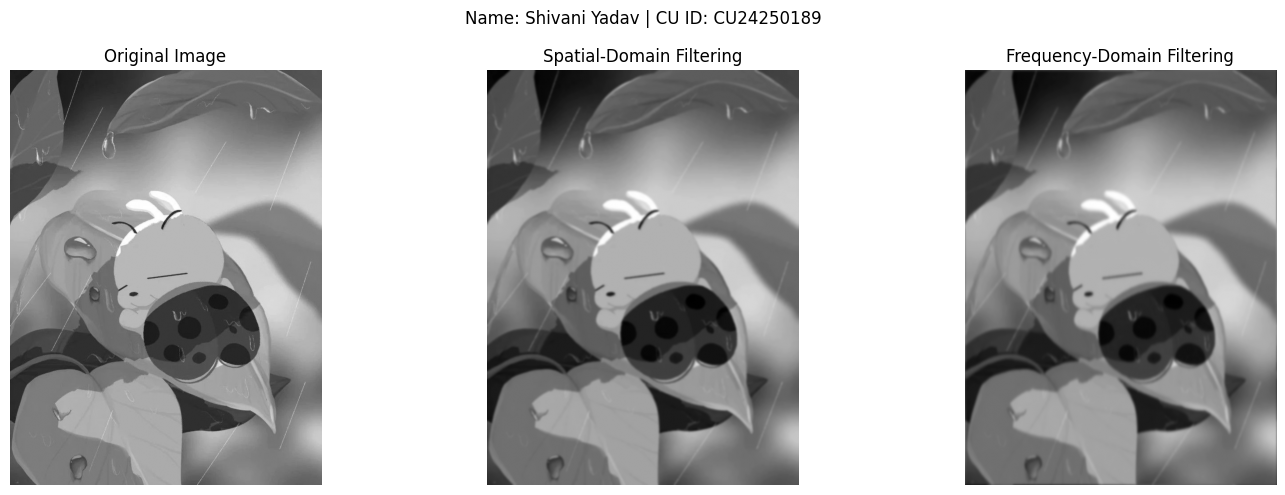

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Student Details
name = "Shivani Yadav"
cu_id = "CU24250189"

# Read image
image = cv2.imread(
    file_name,
    cv2.IMREAD_GRAYSCALE
)

# ---------------------------------
# Spatial-Domain Gaussian Filtering
# ---------------------------------

spatial_result = cv2.GaussianBlur(
    image,
    (11, 11),
    0
)

# ---------------------------------
# Frequency-Domain Gaussian Filtering
# ---------------------------------

rows, cols = image.shape

center_row = rows // 2
center_col = cols // 2

# Fourier Transform
dft = np.fft.fft2(image)
dft_shift = np.fft.fftshift(dft)

# Distance matrix
y, x = np.ogrid[:rows, :cols]

distance = np.sqrt(
    (x - center_col) ** 2 +
    (y - center_row) ** 2
)

# Gaussian frequency filter
cutoff = 50

gaussian_filter = np.exp(
    -(distance ** 2) /
    (2 * cutoff ** 2)
)

# Apply filter
filtered_spectrum = (
    dft_shift * gaussian_filter
)

# Inverse Fourier Transform
frequency_result = np.abs(
    np.fft.ifft2(
        np.fft.ifftshift(
            filtered_spectrum
        )
    )
)

frequency_result = np.clip(
    frequency_result,
    0,
    255
).astype(np.uint8)

# ---------------------------------
# Display Comparison
# ---------------------------------

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(spatial_result, cmap="gray")
plt.title("Spatial-Domain Filtering")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(frequency_result, cmap="gray")
plt.title("Frequency-Domain Filtering")
plt.axis("off")

plt.suptitle(
    f"Name: {name} | CU ID: {cu_id}"
)

plt.tight_layout()
plt.show()